In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
import pickle

In [18]:
url = "https://docs.google.com/spreadsheets/d/1Es5Cvfa-HUWnhJ0qfWu6HGCEmuQxefjjP7zUuGzUX_g/export?format=csv&gid=899247574"
autism_dataset = pd.read_csv(url)

In [19]:
autism_dataset.drop(columns=['Case_No', 'Unnamed: 11'], inplace=True)

In [20]:
autism_dataset.dropna(inplace=True)

In [21]:
autism_dataset = pd.get_dummies(autism_dataset)

In [22]:
print(autism_dataset.columns)

Index(['A1-Does your child look at you when you call his/her name?',
       'A2- is it easy for you to get eye contact with your child? ',
       'A3-Does your child point to indicate that s/he wants something?\n(out of reach) ',
       'A3-Does your child point to indicate that s/he wants something? \n(out of reach) ',
       'A5-Does the individual struggle with imaginative or pretend play?(e.g. care for dolls, talk on a toy phone) ',
       'A6-Is your child hypersensitive( light, sound, touch, or taste)?',
       'A7-If you or someone else in the family is visibly upset, does your child show signs \nof wanting to comfort them? (e.g. stroking hair, hugging them)',
       'A8-Did your child have birth complications or history of infection or illness during early childhood?',
       'A9-Does your child use simple gestures? (e.g. wave goodbye) ',
       'A10-Does your child stare at nothing with no apparent purpose? ',
       'Age_in_months', 'Qchat-10-Score',
       'ISAA(Indian scale

In [23]:
autism_dataset['Who completed the test'] = autism_dataset['Who completed the test_Health Care Professional'] | autism_dataset['Who completed the test_Health care professional']

In [24]:
autism_dataset.drop(columns=['Who completed the test_Health Care Professional', 'Who completed the test_Health care professional'],inplace=True)

In [25]:
print(autism_dataset.columns)

Index(['A1-Does your child look at you when you call his/her name?',
       'A2- is it easy for you to get eye contact with your child? ',
       'A3-Does your child point to indicate that s/he wants something?\n(out of reach) ',
       'A3-Does your child point to indicate that s/he wants something? \n(out of reach) ',
       'A5-Does the individual struggle with imaginative or pretend play?(e.g. care for dolls, talk on a toy phone) ',
       'A6-Is your child hypersensitive( light, sound, touch, or taste)?',
       'A7-If you or someone else in the family is visibly upset, does your child show signs \nof wanting to comfort them? (e.g. stroking hair, hugging them)',
       'A8-Did your child have birth complications or history of infection or illness during early childhood?',
       'A9-Does your child use simple gestures? (e.g. wave goodbye) ',
       'A10-Does your child stare at nothing with no apparent purpose? ',
       'Age_in_months', 'Qchat-10-Score',
       'ISAA(Indian scale

In [26]:
X = autism_dataset.drop(columns=['Who completed the test_family member', 'Who completed the test'])
y = autism_dataset['Who completed the test_family member']


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [30]:
y_pred = rf_classifier.predict(X_test_scaled)

In [31]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.976303317535545


In [32]:
smote = SMOTE(random_state=42)

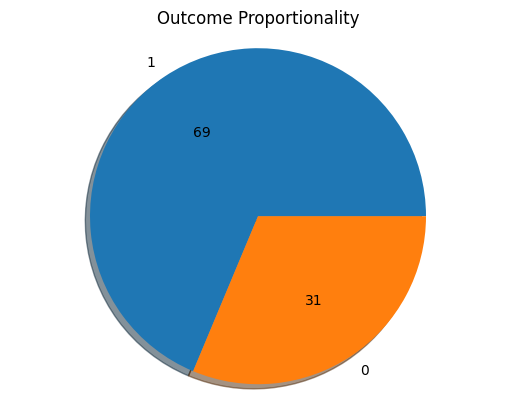

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
url = "https://docs.google.com/spreadsheets/d/1Es5Cvfa-HUWnhJ0qfWu6HGCEmuQxefjjP7zUuGzUX_g/export?format=csv&gid=899247574"
df = pd.read_csv(url)

# Assuming the column containing outcomes is 'Class/ASD Traits' in your dataset
# Replace 'Class/ASD Traits' with the appropriate column name if necessary
outcome_counts = df['Class/ASD Traits'].value_counts()

# Plotting the pie chart
plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%.f', shadow=True)
plt.title('Outcome Proportionality')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [35]:
model_filename = "autism_detection_model.pkl"
with open(model_filename, 'wb') as file:
    pickle.dump(rf_classifier, file)

In [36]:
autism_dataset.describe()

,A1-Does your child look at you when you call his/her name?,A2- is it easy for you to get eye contact with your child?,A3-Does your child point to indicate that s/he wants something?\n(out of reach),A3-Does your child point to indicate that s/he wants something? \n(out of reach),"A5-Does the individual struggle with imaginative or pretend play?(e.g. care for dolls, talk on a toy phone)","A6-Is your child hypersensitive( light, sound, touch, or taste)?","A7-If you or someone else in the family is visibly upset, does your child show signs \nof wanting to comfort them? (e.g. stroking hair, hugging them)",A8-Did your child have birth complications or history of infection or illness during early childhood?,A9-Does your child use simple gestures? (e.g. wave goodbye),A10-Does your child stare at nothing with no apparent purpose?,Age_in_months,Qchat-10-Score,"ISAA(Indian scale for assessment of autism(stimming,emotional responsivness))","CARS(childhood autism rating scale(relationship with people, fear and nervousness)",Pupil Diameter,Jaundice,Family_mem_with_ASD,Class/ASD Traits
count,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000
mean,0.563567,0.448767,0.401328,0.512334,0.524668,0.576850,0.649905,0.459203,0.489564,0.586338,27.867173,5.212524,2.994307,30.952562,3.983776,0.273245,0.162239,0.686907
std,0.496178,0.497604,0.490400,0.500085,0.499628,0.494293,0.477226,0.498569,0.500128,0.492723,7.980354,2.907304,1.297951,11.872768,0.209834,0.445837,0.368845,0.463972
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,1.000000,8.000000,3.600000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,3.000000,2.000000,22.000000,3.860000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,30.000000,5.000000,3.000000,33.000000,4.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,36.000000,8.000000,4.000000,38.000000,4.100000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,36.000000,10.000000,5.000000,60.000000,8.780000,1.000000,1.000000,1.000000


In [37]:
def predict_with_saved_model(input_data):
    # Load the saved model
    with open(model_filename, 'rb') as file:
        saved_model = pickle.load(file)
    
    # Standardize the input data using the same scaler object
    input_data_scaled = scaler.transform([input_data])  # Assuming input_data is a list or array
    
    # Make predictions using the saved model
    prediction = saved_model.predict(input_data_scaled)
    
    return prediction

# Example usage:
# input_data = [1,1,0,0,0,1,1,0,0,0,36,4,2,30,3.98,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0]  # Example input data
# input_data = [0,0,0,0,0,0,0,1,0,1,28,2,2,22,3.8,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0]
# input_data = [0,0,0,0,0,0,0,1,0,1,20,2,2,22,3.8,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1]
# input_data = [1,1,1,1,1,1,1,1,1,1,36,10,2,30,4.0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1]
input_data = [0,0,0,1,0,0,0,0,0,0,36,1,2,30,4.0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0]
prediction = predict_with_saved_model(input_data)
print(prediction)
if prediction[0] == 0: 
    print('The person is not with Autism spectrum disorder') 
elif prediction[0] == 1:
    print('The person is with Autism spectrum disorder')
else:
    print('Invalid prediction value')

[ True]
The person is with Autism spectrum disorder


C:\Users\JOSEPH\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
def predict_with_saved_model(input_data):
    # Load the saved model
    with open(model_filename, 'rb') as file:
        saved_model = pickle.load(file)
    
    # Standardize the input data using the same scaler object
    input_data_scaled = scaler.transform([input_data])  # Assuming input_data is a list or array
    
    # Make predictions using the saved model
    prediction = saved_model.predict(input_data_scaled)
    
    return prediction

# Example usage:
# input_data = [1,1,1,1,1,1,1,1,1,1,36,10,2,30,4.0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1]
input_data = [0,0,0,1,0,0,0,0,0,0,36,1,2,30,4.0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0]
prediction = predict_with_saved_model(input_data)
print("Prediction:", prediction)

if prediction[0] == 0: 
    print('The person is not with Autism spectrum disorder') 
elif prediction[0] == 1:
    print('The person is with Autism spectrum disorder')
else:
    print('Invalid prediction value')


Prediction: [ True]
The person is with Autism spectrum disorder


C:\Users\JOSEPH\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [40]:
autism_dataset['Class/ASD Traits'].value_counts()

Class/ASD Traits
1    724
0    330
Name: count, dtype: int64

In [41]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Load your dataset
url = "https://docs.google.com/spreadsheets/d/1Es5Cvfa-HUWnhJ0qfWu6HGCEmuQxefjjP7zUuGzUX_g/export?format=csv&gid=899247574"
autism_dataset = pd.read_csv(url)

# Preprocessing: Drop irrelevant columns, handle missing values, etc.
autism_dataset.drop(columns=['Case_No', 'Unnamed: 11'], inplace=True)
autism_dataset.dropna(inplace=True)

# Encode categorical variables
autism_dataset = pd.get_dummies(autism_dataset)

# Separate features and target variable
X = autism_dataset.drop(columns=['Class/ASD Traits'])
y = autism_dataset['Class/ASD Traits']

# Convert target variable to numerical values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Count the occurrences of each class after applying SMOTE
class_counts_after = pd.Series(y_resampled).value_counts()

# Check if the data is balanced
is_balanced = (class_counts_after.min() / class_counts_after.max()) >= 0.8

# Print class distribution before and after
print("Class distribution before applying SMOTE:")
print(pd.Series(y).value_counts())
print("\nClass distribution after applying SMOTE:")
print(class_counts_after)

# Print whether the data is balanced or not
if is_balanced:
    print("\nThe data is balanced.")
else:
    print("\nThe data is not balanced.")


Class distribution before applying SMOTE:
1    724
0    330
Name: count, dtype: int64

Class distribution after applying SMOTE:
0    724
1    724
Name: count, dtype: int64

The data is balanced.


In [42]:
autism_dataset['Class/ASD Traits'].value_counts()

Class/ASD Traits
1    724
0    330
Name: count, dtype: int64